# Variaciones del mismo digito


### En este notebook se observan distintas reconstrucciones del mismo dígito


#### Datos

Se usaron los datos de MNIST para entrenar los modelos y visualizar las variaciones por dígito (genericamente clase).


#### Modelo


Se usaron los modelos de diminesiones 128_2 y 256_128 (intermedia y latente respectivamente) para visualizar.


In [1]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from project.loader import load

dataset="mnist"

cvae_0 = load.cvae(inter=20,lat=128,dataset=dataset)
cvae_1 = load.cvae(inter=30,lat=128,dataset=dataset)
cvae_2 = load.cvae(inter=40,lat=128,dataset=dataset)
cvae_3 = load.cvae(inter=50,lat=128,dataset=dataset)
cvae_4 = load.cvae(inter=60,lat=128,dataset=dataset)


predictor = load.predictor(dataset)
data =  load.data(dataset)

x_train = data["x_train"]
x_train_1 = data["x_train_1"]
y_train = data["y_train"]
y_train_1 = data["y_train_1"]
x_test = data["x_test"]
y_test  =data["y_test"]

models = load.all_models(dataset=dataset)

2026-01-04 20:14:00.083169: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-04 20:14:00.083585: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-04 20:14:00.086509: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-04 20:14:00.093847: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767568440.105773  847488 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767568440.10

Usando mnist como dataset
Encontrados 9 pares de modelos.


## Visualizaciones:

Variaciones por dígito de cvae_0


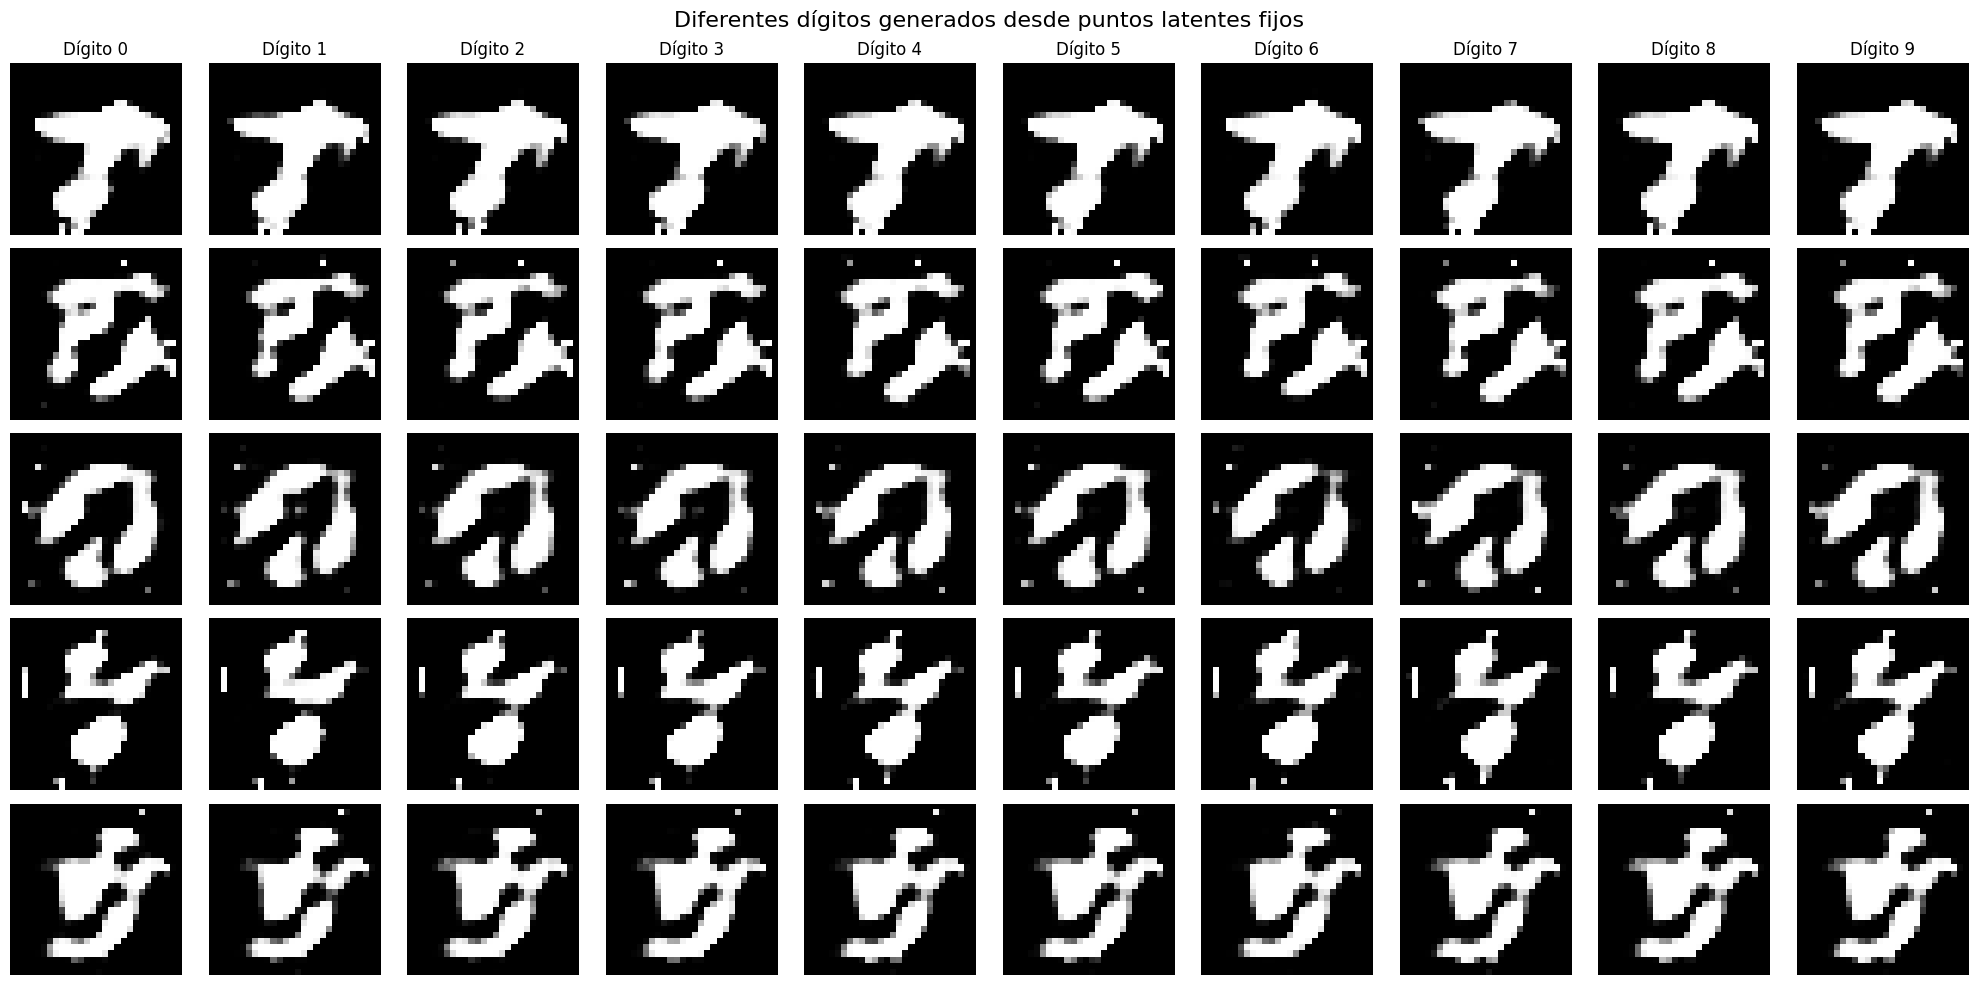

In [2]:
import project.visualizations.visualizations as vis

puntos=vis.variantes_punto_fijo(cvae=cvae_4) #se toma un punto del espacio latente para las reconstrucciones

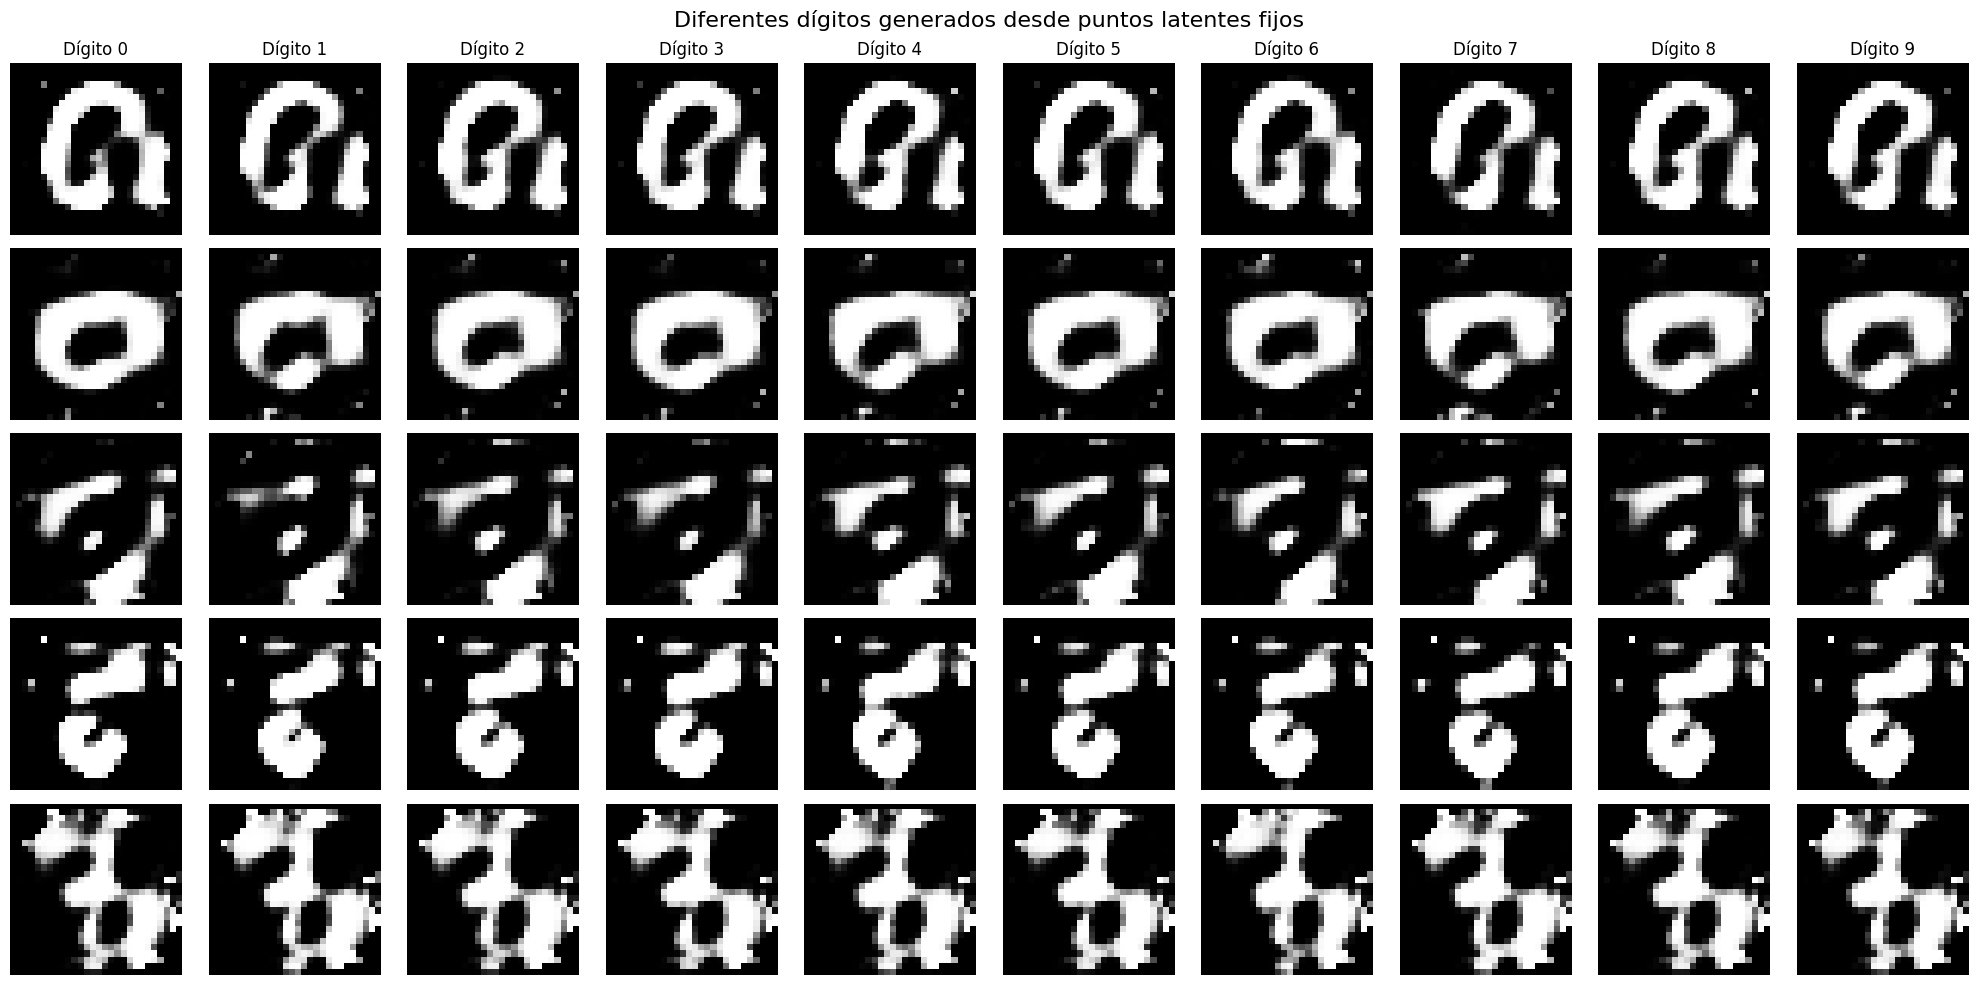

In [3]:
puntos=vis.variantes_punto_fijo(cvae=cvae_1)

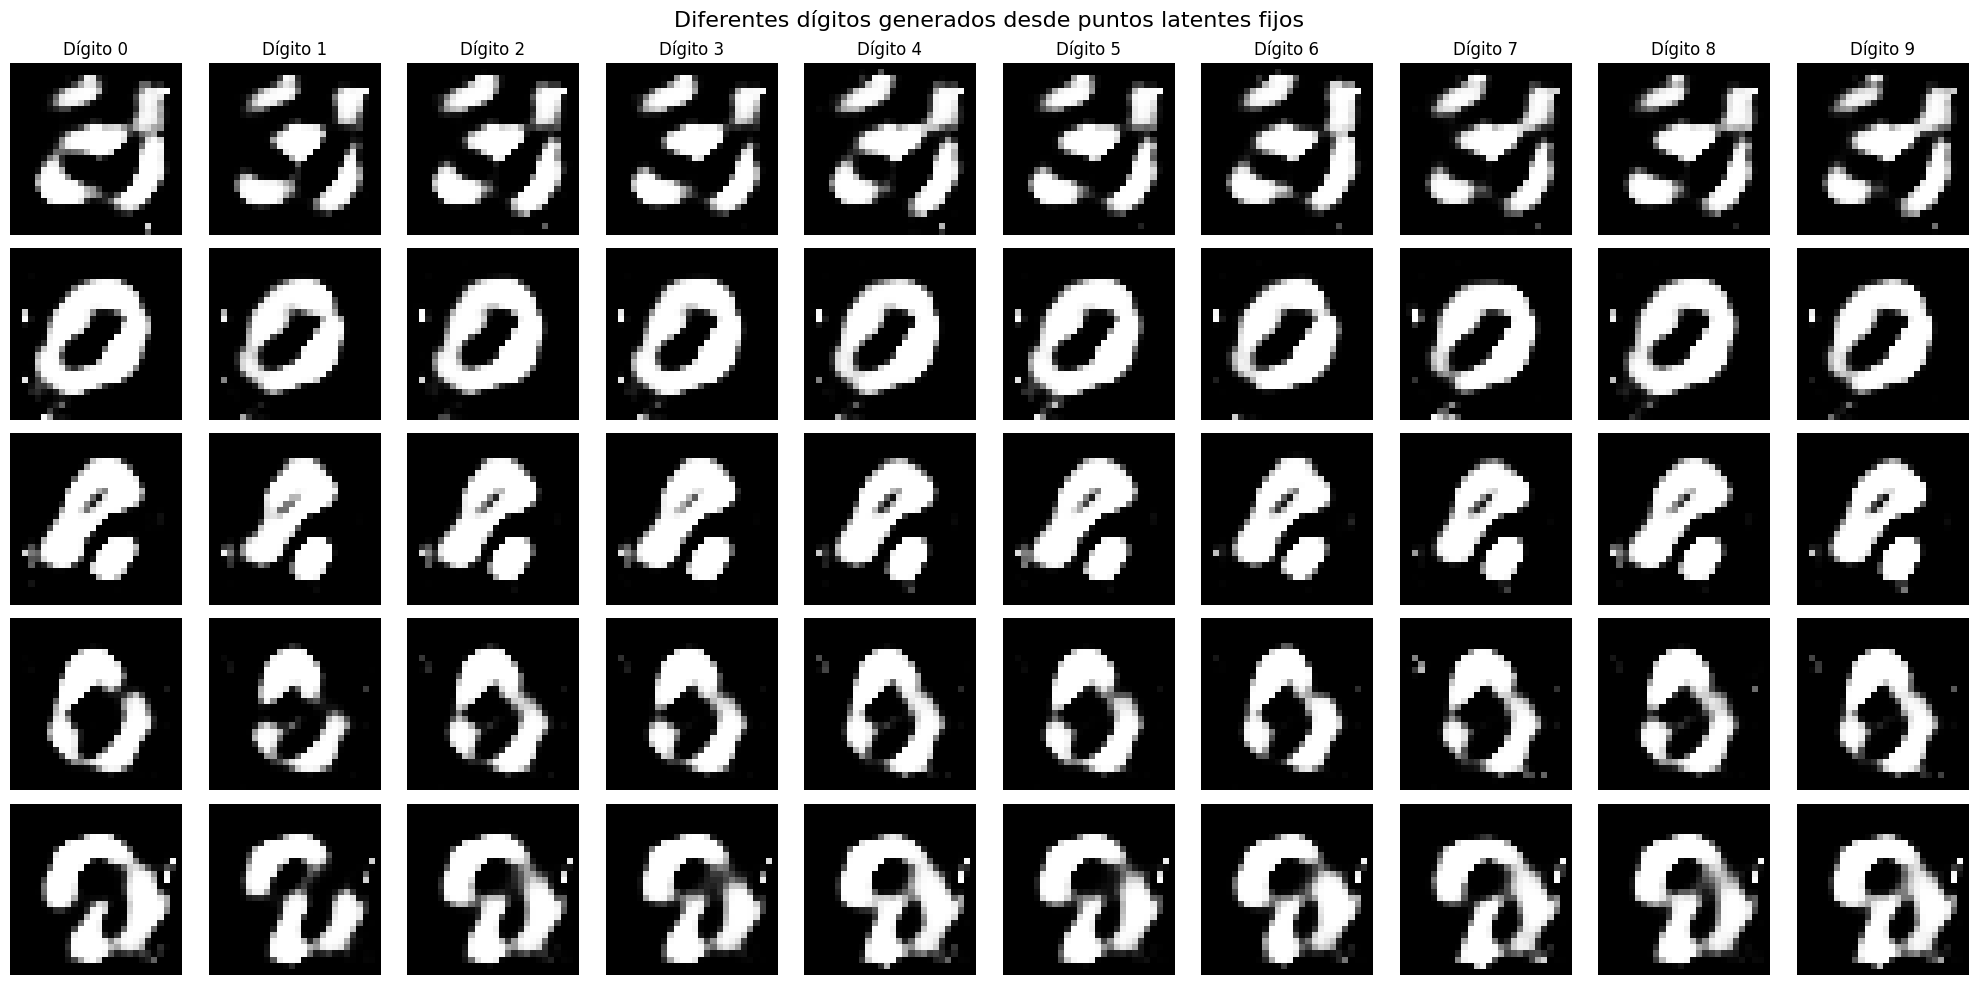

In [4]:
puntos=vis.variantes_punto_fijo(cvae=cvae_2)

Para ambos modelos parece haber una buena reconstrucción de dígitos. Bastante peor en el caso del modelo cvae_0. los modelos fueron entrenados hasta que earystop los freno.




## Condiciones anómalas

condición en el decoder y enconder en 0 o aleatoreo


[[0.82270275 0.96713158 0.39810923 0.38309092 0.61759232 0.43687075
  0.73935714 0.54479912 0.35948887 0.37824017]
 [0.60834544 0.84486288 0.54314591 0.70756381 0.64055222 0.82798716
  0.43109774 0.71485279 0.36830701 0.27852193]
 [0.40473494 0.23647133 0.33576726 0.33159355 0.6071774  0.90500252
  0.29089588 0.36460857 0.24193625 0.73199407]
 [0.7828944  0.5040721  0.42439436 0.53706851 0.21058868 0.72276053
  0.44226629 0.48521864 0.46411434 0.6246217 ]
 [0.28526831 0.99432196 0.27804457 0.67061684 0.27365395 0.22293257
  0.53321746 0.74997085 0.36236382 0.17203535]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


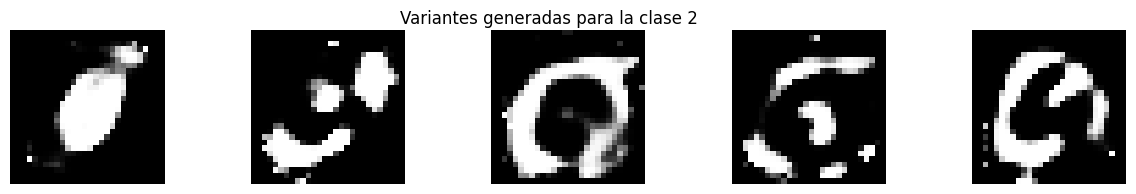

array([[-4.48079376e-01, -4.81883756e-01, -1.27402758e-01,
         1.45918817e-01,  5.20332135e-01,  1.85893516e+00,
         2.56629083e-01,  3.83674601e-01, -1.94778632e+00,
        -3.24005669e-01,  3.54476086e-01,  3.09319533e-01,
        -8.87124929e-01,  4.01469470e-02, -1.27701171e-01,
        -1.37065458e-01,  6.46916106e-02,  1.24407292e+00,
        -6.89319460e-01,  2.71680501e-01,  9.48645075e-01,
        -1.25994388e+00,  1.40415376e+00, -9.78166714e-01,
         9.06855083e-01, -1.48486630e+00, -1.52563886e-01,
         6.15967994e-01, -7.43424220e-01, -5.00308315e-02,
        -2.89515983e-01, -2.10086672e-01, -9.33068261e-01,
        -1.14771895e+00, -2.06412531e+00, -9.17926952e-01,
         2.03725249e+00, -1.94095153e+00, -9.45202338e-02,
         1.30223670e+00,  9.20622265e-01, -8.82624968e-01,
         1.89714738e-01, -1.08945450e+00, -1.64576273e+00,
        -1.52505228e+00,  7.16560146e-01,  3.44476064e-01,
        -7.40664637e-01, -1.22330528e+00,  7.54650011e-0

In [5]:
import project.visualizations.visualizations as vis
import importlib
import numpy as np

importlib.reload(vis)
num_variantes = 5
custom_condition = np.zeros(shape=(num_variantes, 10))
custom_condition = np.random.uniform(0,1,size=(num_variantes,10))
"""
1) probar poner 0s al encoder.

2) entrenar un encoder sin clases en la entrada (quizas ponerle 0 en la entrada, sino cambiar 
                                                la arquitectura para que no tenga condicion. Verficar si es lo mismo)


"""
print(custom_condition)
vis.variantes(
    cvae=cvae_0,
    condicion_id=2,
    num_variantes=num_variantes,
    custom_condition=custom_condition,
)